# DATA ANALYSIS INSIGHTS AND LOAD

In [1]:
# import libraries
import pandas as pd 
import numpy as np 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
# load the file and dataset
#file_path = ("/data/ESK10705.csv")
df = pd.read_csv("data/ESK10705.csv")
df2 = pd.read_csv("data/Prepaid_electricity_by_suburb.csv")
# Check if first column is mistakenly set as index
df.reset_index(inplace=True)



In [3]:
# Shift column headers left
df.columns = df.columns[1:].to_list() + [df.columns[0]]

In [4]:
# Convert DateTime column to actual datetime format
df["Date Time Hour Beginning"] = pd.to_datetime(df["Date Time Hour Beginning"], errors="coerce")



# Convert DateTime to numeric (UNIX timestamp in seconds)
#df["Date Time Hour Beginning"] = df["Date Time Hour Beginning"].astype("int64") // 10**9  # Convert to seconds

In [5]:
#Display the basic information of the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 43 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date Time Hour Beginning               43824 non-null  datetime64[ns]
 1   Original Res Forecast before Lockdown  24120 non-null  float64       
 2   Residual Forecast                      43824 non-null  float64       
 3   RSA Contracted Forecast                43824 non-null  float64       
 4   Dispatchable Generation                39240 non-null  float64       
 5   Residual Demand                        39240 non-null  float64       
 6   RSA Contracted Demand                  39240 non-null  float64       
 7   International Exports                  39240 non-null  float64       
 8   International Imports                  39240 non-null  float64       
 9   Thermal Generation                     39240 non-null  float6

In [6]:
df.head()
df.describe()

,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,Nuclear Generation,...,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index
count,24120.000000,43824.000000,43824.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,...,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39240.000000,39195.000000
mean,25696.925347,23700.770265,25547.244327,22973.649457,23741.517778,25585.334157,1419.392279,1190.605469,20240.458491,1116.229206,...,46474.117431,5224.077374,12618.057310,895.329616,13512.890443,451.386432,271.817542,81.952813,41.894341,38.319847
std,2976.391694,2799.966755,3117.433911,2867.049708,2909.497496,3186.250654,198.440842,234.755483,2062.035469,393.047135,...,734.245777,1674.349756,2798.536562,623.097283,2575.247684,305.519835,389.300775,11.150085,9.508021,9.795411
min,17962.121000,14319.136000,15172.651000,13797.940000,13797.940000,14929.991000,587.054000,0.000000,13774.000000,-47.584000,...,44926.000000,895.000000,4670.626000,0.000000,6545.000000,0.000000,0.000000,18.300000,9.100000,10.300000
25%,23179.918500,21469.599000,22744.575000,20783.069500,21454.851750,22744.998000,1275.258750,1105.000000,18807.717250,910.000000,...,46329.000000,4085.937500,10457.069750,432.609000,11518.000000,162.000000,0.000000,75.400000,35.500000,31.380000
50%,25975.684000,23831.508500,26120.454000,22868.432000,23856.108500,26163.909500,1407.869500,1198.000000,20167.625000,922.990000,...,46686.000000,5226.000000,12998.704500,723.572000,13788.500000,441.000000,0.000000,84.600000,43.700000,38.540000
75%,27773.274000,25627.277500,27977.289750,25042.186750,25734.662500,28011.403500,1554.288000,1355.711750,21690.732750,1407.000000,...,46800.000000,6306.240000,14765.524500,1259.820000,15430.000000,717.000000,544.000000,90.300000,49.600000,45.400000
max,34900.376000,33008.667000,34567.494000,32383.649000,34029.030000,35004.746000,2298.443000,1765.000000,26591.300000,1852.000000,...,47520.000000,11289.417000,19507.807000,5219.432000,21535.000000,1268.000000,1957.000000,102.000000,58.700000,66.400000


In [7]:
# For cape town dataset
df2.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7685 entries, 0 to 7684
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            7678 non-null   object 
 1   units_per_area  7685 non-null   float64
 2   txmonth         7685 non-null   object 
 3   number_in_area  7685 non-null   int64  
 4   tariff          7685 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 300.3+ KB


In [8]:
# Summary of dataset 2
df2.head()

,area,units_per_area,txmonth,number_in_area,tariff
0,BEACON VALLEY,1009307.4,Nov-24,3447,Domestic
1,EASTRIDGE,810164.4,Nov-24,2860,Domestic
2,NaN,2672144.1,Nov-24,9403,Domestic
3,LENTEGEUR,1243236.9,Nov-24,4420,Domestic
4,ROCKLANDS,1075632.9,Nov-24,3669,Domestic


In [9]:
# Drop columns with too many missing values (threshold: 50% missing)
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)
df.head()

,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index
0,2020-04-01 00:00:00,21964.211,15973.653,16700.031,15695.40,15695.40,16758.232,1704.954,1069.0,15560.0,...,45017.0,8954.3,8233.256,903.962,9137.0,218.0,498.0,86.2,44.8,21.69
1,2020-04-01 01:00:00,21486.852,15649.973,16357.728,15450.27,15450.27,16401.964,1716.990,938.0,15423.0,...,45017.0,8930.0,8224.320,903.962,9128.0,282.0,495.0,88.2,46.8,24.79
2,2020-04-01 02:00:00,21366.136,15452.154,16136.543,15211.40,15211.40,16136.822,1691.063,848.0,15319.0,...,45017.0,8930.0,8284.563,903.962,9188.0,525.0,492.0,89.7,48.0,28.22
3,2020-04-01 03:00:00,21535.832,15572.487,16222.955,15206.27,15206.27,16169.168,1657.440,831.0,15317.0,...,45017.0,8751.4,8571.934,903.962,9475.0,896.0,492.0,91.2,50.0,31.44
4,2020-04-01 04:00:00,22623.152,16011.992,16623.471,15574.27,15574.27,16502.843,1640.295,944.0,15506.0,...,45017.0,8742.0,8406.206,903.962,9310.0,168.0,499.0,93.0,52.0,34.79


In [10]:
# Fill remaining missing values with column mean
df.fillna(df.mean(), inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_13948\2772816096.py:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  df.fillna(df.mean(), inplace=True)


In [11]:
# Display updated dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 43 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date Time Hour Beginning               43824 non-null  datetime64[ns]
 1   Original Res Forecast before Lockdown  43824 non-null  float64       
 2   Residual Forecast                      43824 non-null  float64       
 3   RSA Contracted Forecast                43824 non-null  float64       
 4   Dispatchable Generation                43824 non-null  float64       
 5   Residual Demand                        43824 non-null  float64       
 6   RSA Contracted Demand                  43824 non-null  float64       
 7   International Exports                  43824 non-null  float64       
 8   International Imports                  43824 non-null  float64       
 9   Thermal Generation                     43824 non-null  float6

In [12]:
df.head()

,Date Time Hour Beginning,Original Res Forecast before Lockdown,Residual Forecast,RSA Contracted Forecast,Dispatchable Generation,Residual Demand,RSA Contracted Demand,International Exports,International Imports,Thermal Generation,...,Installed Eskom Capacity,Total PCLF,Total UCLF,Total OCLF,Total UCLF+OCLF,Non Comm Sentout,Drakensberg Gen Unit Hours,Palmiet Gen Unit Hours,Ingula Gen Unit Hours,index
0,2020-04-01 00:00:00,21964.211,15973.653,16700.031,15695.40,15695.40,16758.232,1704.954,1069.0,15560.0,...,45017.0,8954.3,8233.256,903.962,9137.0,218.0,498.0,86.2,44.8,21.69
1,2020-04-01 01:00:00,21486.852,15649.973,16357.728,15450.27,15450.27,16401.964,1716.990,938.0,15423.0,...,45017.0,8930.0,8224.320,903.962,9128.0,282.0,495.0,88.2,46.8,24.79
2,2020-04-01 02:00:00,21366.136,15452.154,16136.543,15211.40,15211.40,16136.822,1691.063,848.0,15319.0,...,45017.0,8930.0,8284.563,903.962,9188.0,525.0,492.0,89.7,48.0,28.22
3,2020-04-01 03:00:00,21535.832,15572.487,16222.955,15206.27,15206.27,16169.168,1657.440,831.0,15317.0,...,45017.0,8751.4,8571.934,903.962,9475.0,896.0,492.0,91.2,50.0,31.44
4,2020-04-01 04:00:00,22623.152,16011.992,16623.471,15574.27,15574.27,16502.843,1640.295,944.0,15506.0,...,45017.0,8742.0,8406.206,903.962,9310.0,168.0,499.0,93.0,52.0,34.79


In [13]:
# Separate datetime column
datetime_col = df["Date Time Hour Beginning"]

# Drop DateTime for scaling
df_numeric = df.drop(columns=["Date Time Hour Beginning"])

# Initialize and apply scaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_numeric)

# Apply PCA
pca = PCA(n_components=5)  # Keeping top 5 components
principal_components = pca.fit_transform(df_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

explained_variance, cumulative_variance

# Convert back to DataFrame (optional)
df_scaled = pd.DataFrame(df_scaled, columns=df_numeric.columns)

# Add DateTime column back
df_scaled.insert(0, "Date Time Hour Beginning", datetime_col)

print(df_scaled.head())

  Date Time Hour Beginning  Original Res Forecast before Lockdown  \
0      2020-04-01 00:00:00                               0.236275   
1      2020-04-01 01:00:00                               0.208093   
2      2020-04-01 02:00:00                               0.200966   
3      2020-04-01 03:00:00                               0.210985   
4      2020-04-01 04:00:00                               0.275178   

   Residual Forecast  RSA Contracted Forecast  Dispatchable Generation  \
0           0.088526                 0.078752                 0.102092   
1           0.071208                 0.061103                 0.088903   
2           0.060623                 0.049698                 0.076051   
3           0.067062                 0.054154                 0.075775   
4           0.090578                 0.074804                 0.095575   

   Residual Demand  RSA Contracted Demand  International Exports  \
0         0.093789               0.091072               0.653212   
1   

In [14]:
print("Explained Variance Ratio:", explained_variance)
print("Cumulative Variance:", cumulative_variance)

Explained Variance Ratio: [0.33291754 0.17607652 0.08199602 0.06691244 0.04986509]
Cumulative Variance: [0.33291754 0.50899406 0.59099008 0.65790252 0.70776761]


In [15]:
""" Histograms & KDE:

A bell-shaped curve suggests normality.
Skewed or bimodal shapes indicate non-normality.
 """

' Histograms & KDE:\n\nA bell-shaped curve suggests normality.\nSkewed or bimodal shapes indicate non-normality.\n '

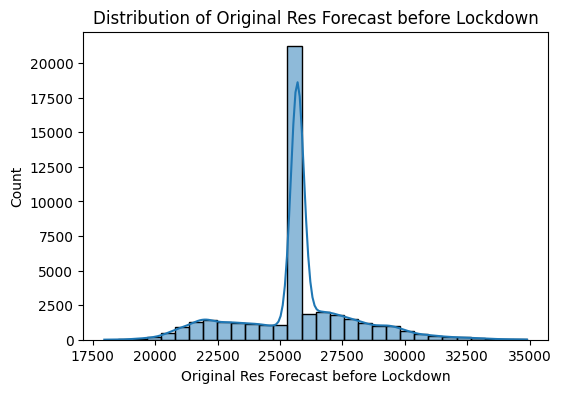

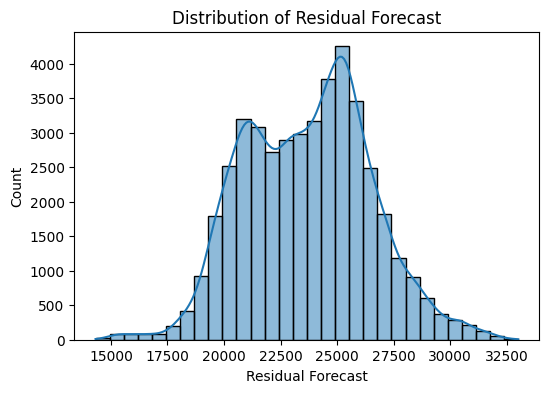

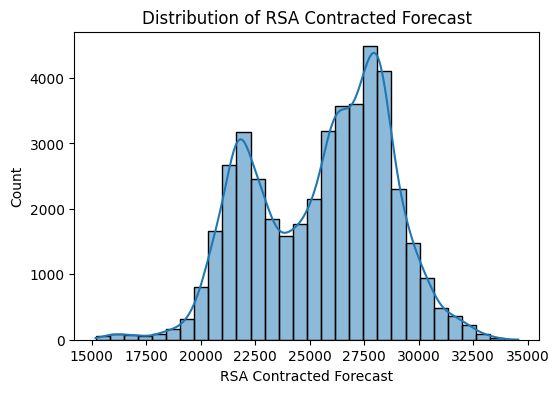

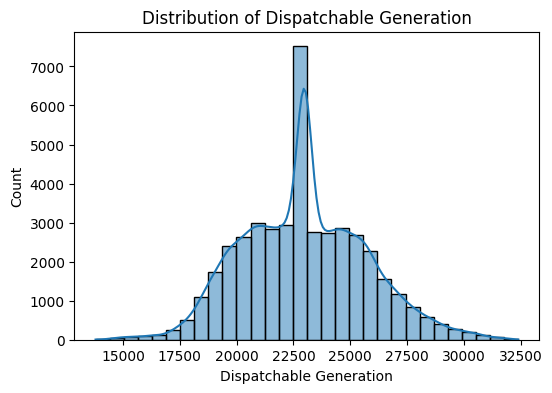

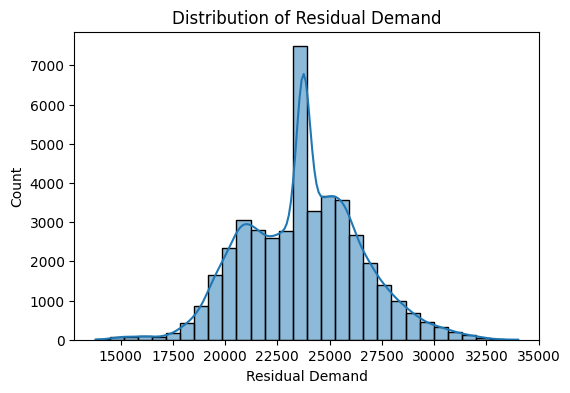

In [16]:
# Select numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Plot histograms & KDE
for col in num_cols[:5]:  # Limit to first 5 columns for better visualization
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()


In [17]:
""" Q-Q Plot:

If data points lie on a straight line → Normal distribution.
Deviations suggest skewness or heavy tails. """

' Q-Q Plot:\n\nIf data points lie on a straight line → Normal distribution.\nDeviations suggest skewness or heavy tails. '

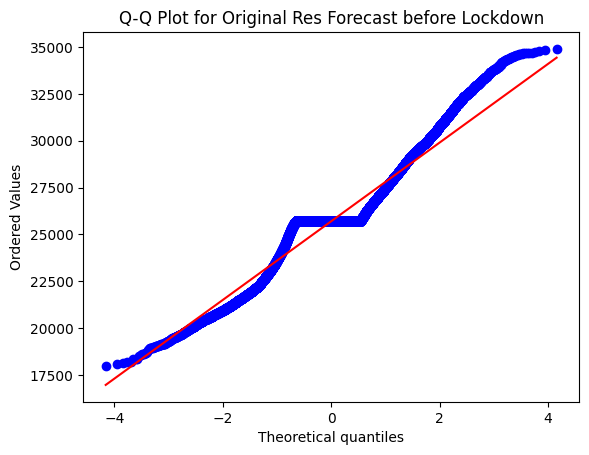

In [18]:
# Q-Q Plot for a sample column
sample_col = num_cols[0]
stats.probplot(df[sample_col], dist="norm", plot=plt)
plt.title(f'Q-Q Plot for {sample_col}')
plt.show()

In [19]:
""" Shapiro-Wilk Test:

p > 0.05 → Fail to reject normality (data might be normal).
p < 0.05 → Data is likely not normal. """

' Shapiro-Wilk Test:\n\np > 0.05 → Fail to reject normality (data might be normal).\np < 0.05 → Data is likely not normal. '

In [20]:
# Shapiro-Wilk test (only for datasets < 5000 samples)
stat, p = stats.shapiro(df[sample_col])
print(f'Shapiro-Wilk Test for {sample_col}: Statistic={stat}, p={p}')
if p > 0.05:
    print("Data is likely normally distributed.")
else:
    print("Data is not normally distributed.")

Shapiro-Wilk Test for Original Res Forecast before Lockdown: Statistic=0.9038184010363547, p=4.7218595286844896e-93
Data is not normally distributed.


c:\users\user\appdata\local\programs\python\python311\lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43824.
  res = hypotest_fun_out(*samples, **kwds)


In [21]:
# Check if there are any non-positive values for log transformation
sample_data = df[sample_col]

# Log transformation (only apply if all values are positive)
if (sample_data > 0).all():
    log_transformed = np.log(sample_data)
else:
    log_transformed = None

# Box-Cox transformation (only for positive values)
boxcox_transformed, boxcox_lambda = stats.boxcox(sample_data[sample_data > 0])

# Yeo-Johnson transformation (works for both positive and negative values)
yeojohnson_transformed, yeojohnson_lambda = stats.yeojohnson(sample_data)

# Prepare the data for display
transformed_data = {
    'Original': sample_data,
    'Log Transformation': log_transformed,
    'Box-Cox Transformation': boxcox_transformed if len(boxcox_transformed) > 0 else None,
    'Yeo-Johnson Transformation': yeojohnson_transformed
}

# Return the transformed data for display and further checks
transformed_data

{'Original': 0        21964.211000
 1        21486.852000
 2        21366.136000
 3        21535.832000
 4        22623.152000
              ...     
 43819    25696.925347
 43820    25696.925347
 43821    25696.925347
 43822    25696.925347
 43823    25696.925347
 Name: Original Res Forecast before Lockdown, Length: 43824, dtype: float64,
 'Log Transformation': 0         9.997170
 1         9.975196
 2         9.969563
 3         9.977473
 4        10.026729
            ...    
 43819    10.154127
 43820    10.154127
 43821    10.154127
 43822    10.154127
 43823    10.154127
 Name: Original Res Forecast before Lockdown, Length: 43824, dtype: float64,
 'Box-Cox Transformation': array([3193.23579673, 3138.76983984, 3124.95483291, ..., 3610.7678216 ,
        3610.7678216 , 3610.7678216 ]),
 'Yeo-Johnson Transformation': array([3193.01135342, 3138.55254612, 3124.73935225, ..., 3610.48846822,
        3610.48846822, 3610.48846822])}

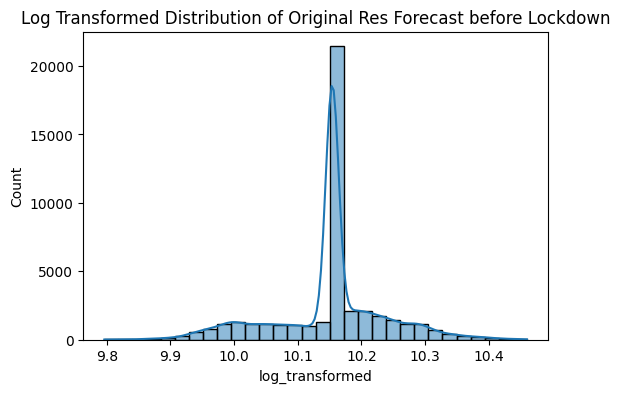

Shapiro-Wilk Test for Log Transformed Original Res Forecast before Lockdown: Statistic=0.9011116103154443, p=9.769905345296487e-94


c:\users\user\appdata\local\programs\python\python311\lib\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 43824.
  res = hypotest_fun_out(*samples, **kwds)


In [22]:
# Check if all values are positive before applying log transformation
if (df[sample_col] > 0).all():
    df['log_transformed'] = np.log(df[sample_col])
else:
    print("Log transformation cannot be applied because there are non-positive values.")


# Box-Cox transformation (only for positive values)
positive_values = df[sample_col][df[sample_col] > 0]
boxcox_transformed, boxcox_lambda = stats.boxcox(positive_values)
df['boxcox_transformed'] = np.concatenate([boxcox_transformed, np.zeros(len(df) - len(positive_values))])

# Yeo-Johnson transformation (works for both positive and negative values)
yeojohnson_transformed, yeojohnson_lambda = stats.yeojohnson(df[sample_col])
df['yeojohnson_transformed'] = yeojohnson_transformed


# Visualize the transformed data
plt.figure(figsize=(6, 4))
sns.histplot(df['log_transformed'], kde=True, bins=30)
plt.title(f'Log Transformed Distribution of {sample_col}')
plt.show()

# Shapiro-Wilk test for normality
stat, p = stats.shapiro(df['log_transformed'])
print(f'Shapiro-Wilk Test for Log Transformed {sample_col}: Statistic={stat}, p={p}')
